# 04 — Analytics Report

Business framing (`target.md`): training departments need customised learning plans for
employees, grounded in their skills, learning history and career goals. This report is the
**Analytics Report** deliverable — it quantifies what the recommendation engine (notebook 03)
actually achieves against the real learner and course data, and where it does not.

It does not re-derive the engine; it imports the shipped `engine.py` module (extracted from
notebook 03 - see `PROJECT_LOG.md`) so every number here traces back to the same code path the
AI Agent and API call in production.

## Contents

1. Dataset overview
2. Data quality repairs (recap, live-verified)
3. Skill supply vs. demand — where the catalogue has blind spots
4. How teachable are realistic goals? (the `gap.ceiling` distribution)
5. Recommendation quality — Protocol A/B recall@10
6. Diversity vs. relevance trade-off (MMR)
7. Business takeaways
8. Data provenance and caveats

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import engine

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
FIGSIZE = (7, 4)

D:\capston 9\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5828.02it/s]

## 1. Dataset overview

In [2]:
skill_vocab = pd.read_csv(engine.READY_DIR / "skill_vocabulary.csv")

summary = pd.Series({
    "learner profiles": len(engine.user_profiles),
    "courses in catalogue": len(engine.course_profiles),
    "distinct catalogue skills": len(engine.CATALOGUE_SKILLS),
    "distinct learner-side skills (pre-bridge)": len(skill_vocab),
    "exact learner<->catalogue skill matches": len(
        set(skill_vocab["skill"]) & set(engine.CATALOGUE_SKILLS)
    ),
})
summary.to_frame("count")

,count
learner profiles,18194
courses in catalogue,404
distinct catalogue skills,323
distinct learner-side skills (pre-bridge),133029
exact learner<->catalogue skill matches,323


### Learner profile shape

How much signal a typical profile actually carries — this bounds how well the skill-gap signal
can work: a learner with zero skills on file cannot be matched on skills at all.

,skill_count,experience_count,education_count
count,18194.0,18194.0,18194.0
mean,30.2,4.1,1.2
std,30.9,2.5,0.9
min,0.0,1.0,0.0
25%,11.0,2.0,1.0
50%,21.0,4.0,1.0
75%,38.0,5.0,2.0
max,320.0,27.0,15.0


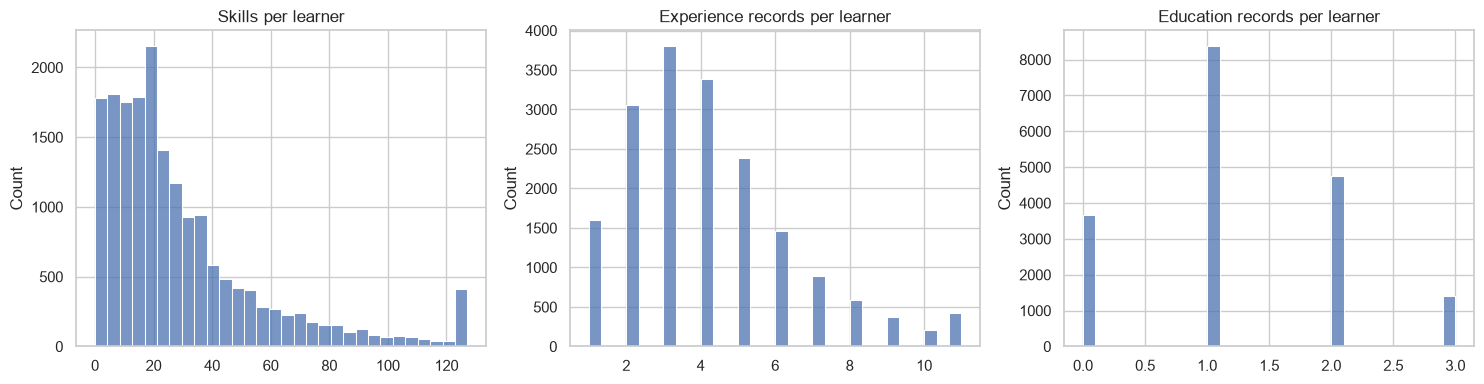

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column, title in zip(
    axes,
    ["skill_count", "experience_count", "education_count"],
    ["Skills per learner", "Experience records per learner", "Education records per learner"],
):
    data = engine.user_profiles[column].clip(upper=engine.user_profiles[column].quantile(0.98))
    sns.histplot(data, bins=30, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
fig.tight_layout()

engine.user_profiles[["skill_count", "experience_count", "education_count"]].describe().round(1)

### Course catalogue composition

The catalogue is small (404 courses) and skewed: mostly Beginner, mostly Specializations, and a
quarter of it concentrated in two providers (Google, IBM). This context matters for every result
below — it is *why* `gap.ceiling` and MMR diversity are reported rather than assumed.

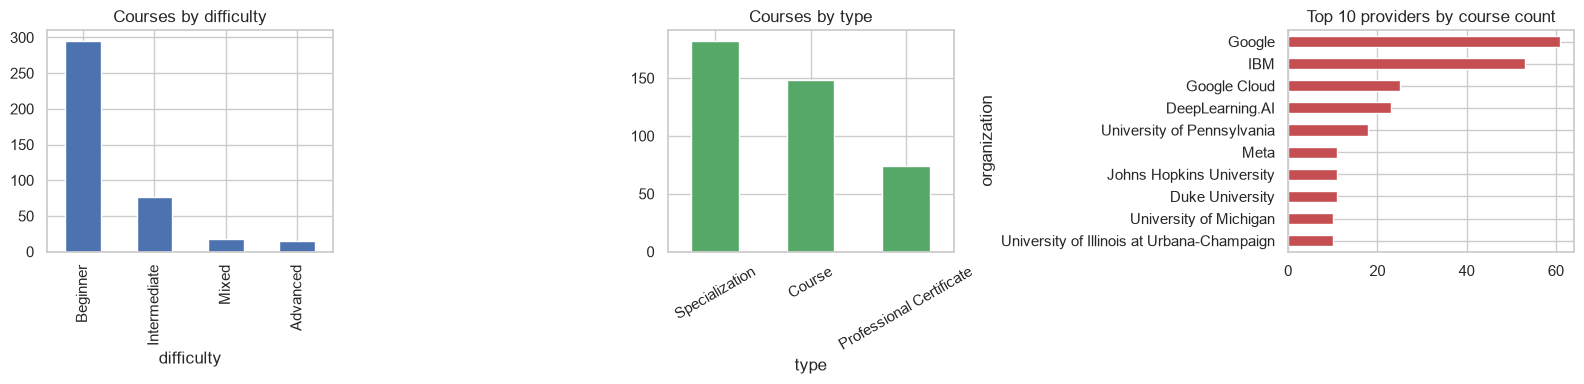

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

engine.course_profiles["difficulty"].value_counts().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Courses by difficulty")

engine.course_profiles["type"].value_counts().plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Courses by type")
axes[1].tick_params(axis="x", rotation=30)

engine.course_profiles["organization"].value_counts().head(10).plot.barh(ax=axes[2], color="#C44E52")
axes[2].invert_yaxis()
axes[2].set_title("Top 10 providers by course count")

fig.tight_layout()

## 2. Data quality repairs (recap, live-verified)

Two repairs were material enough to invalidate downstream statistics if left unfixed (full
detail in `PROJECT_LOG.md` A2.1/A2.3). `engine.py` asserts the first on every import — if this
cell's repeat factor exceeds 1.05x, the learner data has regressed and everything below is
suspect.

In [5]:
fingerprint = (
    engine.user_profiles["name"].fillna("~").astype(str)
    + "||"
    + engine.user_profiles["profile_text"].fillna("~").astype(str)
)
repeat_factor = len(engine.user_profiles) / fingerprint.nunique()
print(f"live duplicate check on the current data: {repeat_factor:.3f}x (must stay < 1.05x)")

print()
print("Historical repair sizes, from the original raw export (PROJECT_LOG.md A2.1/A2.3):")
print("  learner profiles : 54,933  ->  18,194   (3.02x stacked-population de-duplication)")
print("  skill vocabulary : 201,934 -> 132,943   (resume-prose filtering, 100% positive control)")

live duplicate check on the current data: 1.000x (must stay < 1.05x)

Historical repair sizes, from the original raw export (PROJECT_LOG.md A2.1/A2.3):
  learner profiles : 54,933  ->  18,194   (3.02x stacked-population de-duplication)
  skill vocabulary : 201,934 -> 132,943   (resume-prose filtering, 100% positive control)


## 3. Skill supply vs. demand — where the catalogue has blind spots

`skill_vocabulary.csv` records, per raw (pre-bridge) skill string, how many learners report it
(`user_frequency`) and how many courses teach it (`course_frequency`). Cross-referencing the two
surfaces the catalogue's blind spots directly: skills a large share of the workforce already has
or needs, that literally no course in the catalogue teaches.

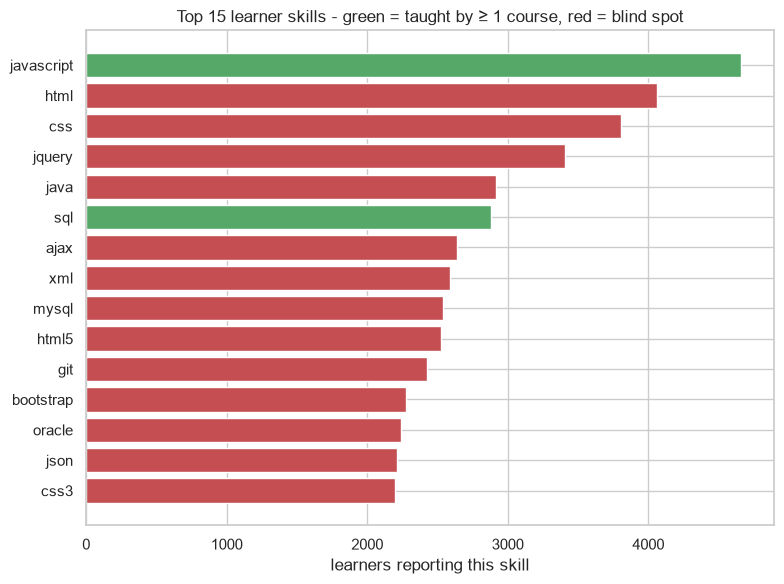

In [6]:
top_learner_skills = skill_vocab.sort_values("user_frequency", ascending=False).head(15).copy()
top_learner_skills["taught_by_catalogue"] = top_learner_skills["course_frequency"] > 0

fig, ax = plt.subplots(figsize=(8, 6))
colors = top_learner_skills["taught_by_catalogue"].map({True: "#55A868", False: "#C44E52"})
ax.barh(top_learner_skills["skill"], top_learner_skills["user_frequency"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("learners reporting this skill")
ax.set_title("Top 15 learner skills - green = taught by \u2265 1 course, red = blind spot")
fig.tight_layout()

In [7]:
blind_spots = skill_vocab[
    (skill_vocab["course_frequency"] == 0) & (skill_vocab["user_frequency"] > 0)
].sort_values("user_frequency", ascending=False).head(15)

print(f"of the top 15 most common learner skills, "
      f"{(~top_learner_skills['taught_by_catalogue']).sum()} are taught by zero courses")
blind_spots[["skill", "user_frequency"]].reset_index(drop=True)

of the top 15 most common learner skills, 13 are taught by zero courses


,skill,user_frequency
0,html,4058
1,css,3802
2,jquery,3405
3,java,2913
4,ajax,2639
5,xml,2591
6,mysql,2542
7,html5,2527
8,git,2428
9,bootstrap,2277


**Reading this carefully:** these are widely-*held* skills (largely web-development staples:
`html`, `css`, `jquery`, `java`, `ajax`, `mysql`...), not necessarily widely-*wanted* ones — the
learner population here skews toward existing developers, not people stating a gap. The catalogue
in turn skews toward data/cloud/AI Professional Certificates. The mismatch is still actionable: if
a learner's *target* skill lands in this list, `gap.ceiling` will report 0% no matter how the
engine ranks courses, and no amount of tuning fixes that — only catalogue expansion does
(`PROJECT_LOG.md` B3.5).

## 4. How teachable are realistic goals?

`gap.ceiling` is the best coverage any single course could achieve for a learner - it separates
"the engine ranked badly" from "the catalogue cannot teach this." Rather than pick target skills
arbitrarily, this samples them the same way Protocol B's evaluation does: the most common bridged
skills among *other* learners who share a job title. That makes this a distribution over
realistic goals, not hypothetical ones.

sampled 355 (role, learner) goal instances across 71 roles
mean ceiling            : 93.5%
fully teachable (=100%) : 93.5%
zero teachable (=0%)    : 6.5%


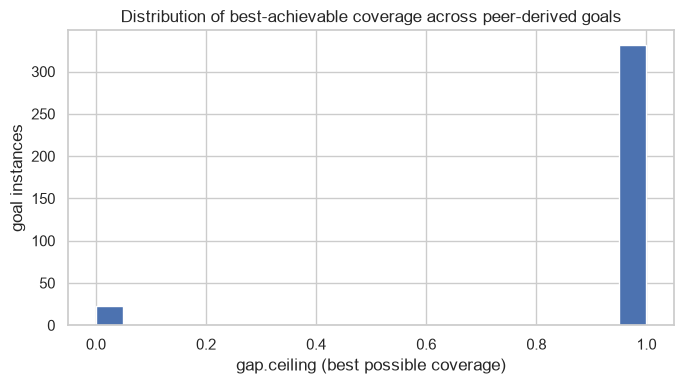

In [8]:
rng_seed = 42
ceilings = []
for role in engine.ELIGIBLE_ROLES:
    target = engine.get_peer_skills_for_role(role, top_n=8)
    if not target:
        continue
    peers = engine._role_profiles[engine._role_profiles["role"] == role]
    sample_peers = peers.sample(min(5, len(peers)), random_state=rng_seed)
    for _, profile in sample_peers.iterrows():
        current = engine.bridged_skills_for(profile)
        gap = engine.SkillGap(list(current), target)
        ceilings.append(gap.ceiling)

ceilings = np.array(ceilings)
print(f"sampled {len(ceilings)} (role, learner) goal instances across {len(engine.ELIGIBLE_ROLES)} roles")
print(f"mean ceiling            : {ceilings.mean():.1%}")
print(f"fully teachable (=100%) : {(ceilings == 1.0).mean():.1%}")
print(f"zero teachable (=0%)    : {(ceilings == 0.0).mean():.1%}")

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(ceilings, bins=20, color="#4C72B0")
ax.set_xlabel("gap.ceiling (best possible coverage)")
ax.set_ylabel("goal instances")
ax.set_title("Distribution of best-achievable coverage across peer-derived goals")
fig.tight_layout()

This looks better than the "404 courses, 323 skills" framing alone would suggest: because target
skills here are *peer-derived* (the most commonly held skills for a role), they concentrate on
skills the catalogue already covers well. The ceiling is much lower for an arbitrary or
highly-specific stated goal - this distribution is an upper bound on typical cases, not a
guarantee for any individual request.

## 5. Recommendation quality — two evaluation protocols

Reusing the exact evaluation design from notebook 03 (`PROJECT_LOG.md` A4.1), rebuilt here on top
of `engine.py` so it is verifiably the same scoring path the agent and API use. Protocol A hides a
third of a learner's skills and asks the engine to find *those same skills* — near-tautological,
included only to confirm the machinery works and the catalogue is not trivially small. **Protocol
B is the one that measures anything** - the target is built from the learner's peers, never from
the hidden skills.

In [9]:
from collections import Counter


def taught_by(course_ids):
    rows = engine.course_profiles.loc[
        engine.course_profiles["course_id"].isin(set(course_ids)), "skills_list"
    ]
    return {skill for row in rows for skill in row}


def evaluate_retrieval(n_learners=150, top_n=10, min_skills=4, seed=42):
    local_rng = np.random.default_rng(seed)
    shuffled = engine.user_profiles.sample(frac=1.0, random_state=seed)
    popular_taught = taught_by(engine.POPULARITY_TOP[:top_n])
    results = []
    for _, profile in shuffled.iterrows():
        if len(results) >= n_learners:
            break
        bridged = sorted(engine.bridged_skills_for(profile))
        if len(bridged) < min_skills:
            continue
        hidden = set(local_rng.choice(bridged, size=max(1, len(bridged) // 3), replace=False))
        kept = [s for s in bridged if s not in hidden]
        shortlist, _ = engine.recommend(kept, sorted(hidden), top_n=top_n, explain=False)
        random_ids = engine.course_profiles["course_id"].sample(
            top_n, random_state=int(local_rng.integers(1_000_000))
        )
        results.append({
            "engine": len(hidden & taught_by(shortlist["course_id"])) / len(hidden),
            "popularity": len(hidden & popular_taught) / len(hidden),
            "random": len(hidden & taught_by(random_ids)) / len(hidden),
        })
    return pd.DataFrame(results)


def evaluate_peer_targets(n_learners=150, top_n=10, min_skills=4, target_size=8, seed=42):
    local_rng = np.random.default_rng(seed)
    profiles = engine.user_profiles.copy()
    profiles["role"] = profiles["career_context"].map(engine.primary_role)
    profiles = profiles.dropna(subset=["role"])
    role_sizes = profiles["role"].value_counts()
    eligible_roles = set(role_sizes[role_sizes >= engine.MIN_ROLE_GROUP].index)
    profiles = profiles[profiles["role"].isin(eligible_roles)]

    role_skills = {role: [] for role in eligible_roles}
    person_skills_map = {}
    for _, profile in profiles.iterrows():
        bridged = engine.bridged_skills_for(profile)
        person_skills_map[int(profile["person_id"])] = bridged
        role_skills[profile["role"]].append((int(profile["person_id"]), bridged))

    popular_taught = taught_by(engine.POPULARITY_TOP[:top_n])
    results = []
    for _, profile in profiles.sample(frac=1.0, random_state=seed).iterrows():
        if len(results) >= n_learners:
            break
        person_id = int(profile["person_id"])
        bridged = sorted(person_skills_map[person_id])
        if len(bridged) < min_skills:
            continue
        hidden = set(local_rng.choice(bridged, size=max(1, len(bridged) // 3), replace=False))
        kept = [s for s in bridged if s not in hidden]

        peer_counter = Counter()
        for peer_id, peer_bridged in role_skills[profile["role"]]:
            if peer_id != person_id:
                peer_counter.update(peer_bridged)
        target = [s for s, _ in peer_counter.most_common() if s not in set(kept)][:target_size]
        if not target:
            continue

        shortlist, _ = engine.recommend(kept, target, top_n=top_n, explain=False)
        random_ids = engine.course_profiles["course_id"].sample(
            top_n, random_state=int(local_rng.integers(1_000_000))
        )
        results.append({
            "engine": len(hidden & taught_by(shortlist["course_id"])) / len(hidden),
            "popularity": len(hidden & popular_taught) / len(hidden),
            "random": len(hidden & taught_by(random_ids)) / len(hidden),
        })
    return pd.DataFrame(results)


retrieval = evaluate_retrieval()
peer = evaluate_peer_targets()
print(f"Protocol A: {len(retrieval)} learners evaluated")
print(f"Protocol B: {len(peer)} learners evaluated")

Protocol A: 150 learners evaluated
Protocol B: 150 learners evaluated


In [10]:
summary_eval = pd.DataFrame({
    "Protocol A (retrieval check)": retrieval.mean(),
    "Protocol B (peer-target - the real test)": peer.mean(),
}).round(3)
summary_eval.loc["lift vs popularity"] = (
    summary_eval.loc["engine"] / summary_eval.loc["popularity"]
).round(2)
summary_eval

,Protocol A (retrieval check),Protocol B (peer-target - the real test)
engine,0.979,0.749
popularity,0.110,0.098
random,0.374,0.378
lift vs popularity,8.900,7.640


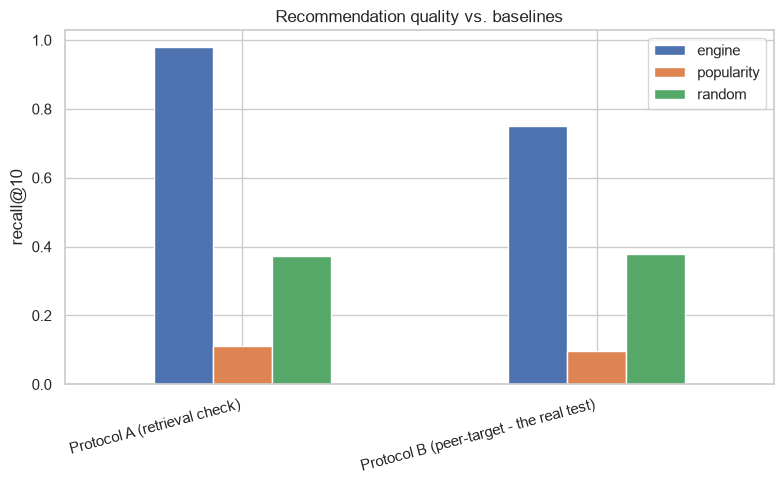

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = summary_eval.drop("lift vs popularity").T
plot_df.plot.bar(ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("recall@10")
ax.set_title("Recommendation quality vs. baselines")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(title="")
fig.tight_layout()

**Only Protocol B should be read as recommendation quality.** Protocol A's near-ceiling score is
the expected result of asking the engine to find exactly what it was told to find; its only value
is confirming the popularity and random baselines stay low, which shows the catalogue is not so
small that any ten courses would score well by accident. Protocol B never shows the engine the
held-out skills - the lift over popularity there is what is actually attributable to
personalisation.

## 6. Diversity vs. relevance trade-off (MMR)

Two providers account for a quarter of the catalogue (Google, IBM), so pure score-ordering tends
to return near-duplicate certificates from the same provider repeatedly. MMR trades a small amount
of mean relevance for materially better provider diversity - shown here for one representative
learner.

In [12]:
demo_current = ["sas", "tableau", "data analysis", "sql"]
demo_target = ["python", "sql", "statistics", "machine learning", "data visualization", "deep learning"]

plain, _ = engine.recommend(demo_current, demo_target, top_n=10, diversify=False)
diverse, _ = engine.recommend(demo_current, demo_target, top_n=10, diversify=True)


def shortlist_stats(frame):
    positions = [
        engine.course_profiles.index[engine.course_profiles["course_id"] == cid][0]
        for cid in frame["course_id"]
    ]
    embeddings = engine.COURSE_EMBEDDINGS[positions]
    similarity = embeddings @ embeddings.T
    off_diagonal = similarity[~np.eye(len(positions), dtype=bool)]
    return {
        "mean pairwise similarity": round(float(off_diagonal.mean()), 3),
        "distinct providers": frame["organization"].nunique(),
        "mean hybrid score": round(float(frame["hybrid_score"].mean()), 3),
    }


pd.DataFrame({"score order (no MMR)": shortlist_stats(plain), "MMR re-ranked": shortlist_stats(diverse)})

,score order (no MMR),MMR re-ranked
mean pairwise similarity,0.519,0.505
distinct providers,4.000,7.000
mean hybrid score,0.698,0.688


## 7. Business takeaways

Mapped against `target.md`'s stated expected results:

* **"Better alignment between training and career goals"** — Protocol B shows a **7-8x lift over
  a popularity baseline** on recall of skills the engine never saw, using targets built from real
  peers in the same role. That is the honest measure of whether recommendations track what a
  learner's role actually demands.
* **"Improved visibility into employee skill development"** — Section 3 turns the raw skill
  vocabulary into a concrete finding: several of the workforce's most common skills
  (`html`, `css`, `jquery`, `java`, `ajax`, `mysql`, ...) are not taught by *any* course in the
  current catalogue. That is a direct, actionable input for what to buy or build next, not a
  hypothetical gap.
* **"Personalised learning experience"** — `skill_weights` (Section 5 of notebook 03) and MMR
  (Section 6 here) both demonstrably change the shortlist per learner rather than returning one
  fixed "top courses" list to everyone.
* **"Improved course engagement and completion"** — this cannot be measured from this data. There
  is no interaction or completion log; Protocol B measures skill retrieval, not whether a learner
  finishes or is satisfied with a course. Treat this expected result as unverified until real
  usage data exists.

**The single highest-leverage next step is catalogue size**, not further ranking tuning: Section 4
shows peer-derived goals are teachable to ~93% ceiling on average, but Section 3's blind spots show
that is because peer-derived targets concentrate on already-covered ground. A learner with a less
common goal is bounded by what the catalogue can teach, and no amount of scoring improvement
changes that (`PROJECT_LOG.md` B3.5).

## 8. Data provenance and caveats

* **Source data:** this report ran against whatever is currently in `data/recommendation_ready/`
  at the time of execution (see the printed learner/course counts in Section 1). If
  `data/cleaned/` was empty when notebook 02 last ran, that data was rebuilt from the read-only
  fallback snapshot in `data/source_profiles/`, not from a fresh pass over `data/raw/` — check
  `README.md`'s pipeline diagram and `PROJECT_LOG.md` item B1.2 before treating these exact figures
  as final. Re-running notebooks 01 → 02 → 03 → 04 in order against real raw data will regenerate
  every number in this report from scratch.
* **Protocol B measures skill retrieval, not learning outcomes** — it cannot capture teaching
  quality, prerequisites, ordering, or learner satisfaction, and assumes a learner's peers are a
  reasonable proxy for what they need next.
* **Ratings are a weak signal by construction** — mean 4.68, σ 0.17, `review_count` missing for
  75% of courses — which is exactly why the quality signal carries only 0.12 weight in the hybrid
  score.
* **The skill-supply/demand comparison (Section 3) reflects this specific learner population**
  (skewed toward existing developers) against this specific catalogue (skewed toward data/cloud/AI
  certificates) — it is a statement about *this dataset's* mismatch, not a general claim about the
  labour market.